## Логистическая регрессия для фейк/реальная

In [31]:
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

In [32]:
train_data = load_npz("x_train_tfidf.npz")
test_data = load_npz("x_test_tfidf.npz")

загружаем выборки из tf-idf

In [33]:
X_train = train_data[:, :-1]
y_train = np.array(train_data[:, -1].todense()).ravel()

X_test = test_data[:, :-1]
y_test = np.array(test_data[:, -1].todense()).ravel()

In [34]:
par = {"C": np.logspace(-1, 1, 5)} 
scoring = {"roc_auc": "roc_auc","precision": make_scorer(precision_score),"recall": make_scorer(recall_score),"f1": make_scorer(f1_score),}

будем выбирать по recall так как нам страшнее пропустить фейк
также рассматриваем параметрр сага, так как он хорошо работает с обоими регуляризациями

In [35]:
grid = GridSearchCV(LogisticRegression(max_iter=1000, solver="saga"),param_grid=par,cv=3,scoring=scoring,refit="roc_auc", 
    verbose=1,)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'C': array([ 0.1 ... 10. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': make_scorer(f...hod='predict'), 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict'), 'roc_auc': 'roc_auc'}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation tim

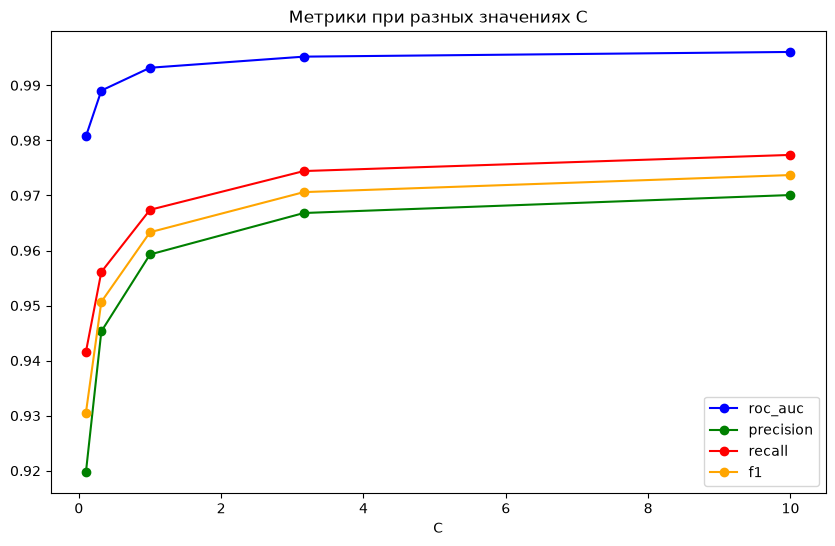

In [36]:
res = grid.cv_results_
c = res["param_C"].data.astype(float)
plt.figure(figsize=(10, 6))
for m, col in [("roc_auc", "blue"), ("precision", "green"), ("recall", "red"), ("f1", "orange")]:
    scores = res[f"mean_test_{m}"]
    plt.plot(c, scores, marker="o", color=col, label=m)

plt.xlabel("C")
plt.title("Метрики при разных значениях C")
plt.legend()

С увеличением параметра C все метрики монотонно возрастают, что свидетельствует о том, что ослабление регуляризации улучшает качество модели на данном датасете. При C=10 наблюдается замедление прироста метрик. Дальнейшее увеличение C даст незначительный прирост качества при риске переобучения. Значит берем оптимальный - 10.

In [37]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

              precision    recall  f1-score   support

    Реальные       0.98      0.97      0.98      7006
        Фейк       0.97      0.98      0.98      7421

    accuracy                           0.98     14427
   macro avg       0.98      0.98      0.98     14427
weighted avg       0.98      0.98      0.98     14427



Text(0.5, 1.0, 'матрица ошибок (C=10)')

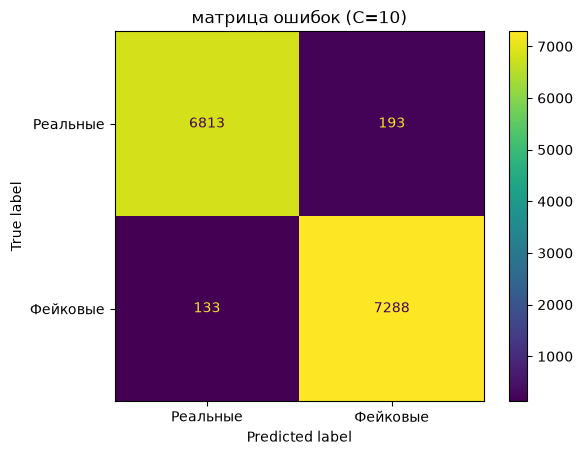

In [38]:
print(classification_report(y_test, y_pred, target_names=["Реальные", "Фейк"]))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Реальные", "Фейковые"])
plt.title(f"матрица ошибок (C=10)")

In [39]:
print(f"""
C: {grid.best_params_['C']:.4f}
рок аук на кросс-валидации: {grid.best_score_:.4f}
рок аук на тесте: {roc_auc_score(y_test, y_proba):.4f}
""")


C: 10.0000
рок аук на кросс-валидации: 0.9961
рок аук на тесте: 0.9969



кратко:
данные загружены из тф-айдиф матриц,
параметр регуляризации C подобран черезгридсерч с тремя фолдами кросс-валидацией
по метрике рок аук на 5 значениях в диапазоне [0.1, 10]

In [40]:
pr_auc = average_precision_score(y_test, y_proba)
pr_auc

0.997062338095295

In [41]:
pr_auc = average_precision_score(y_test, y_proba)
precision, recall, i = precision_recall_curve(y_test, y_proba)

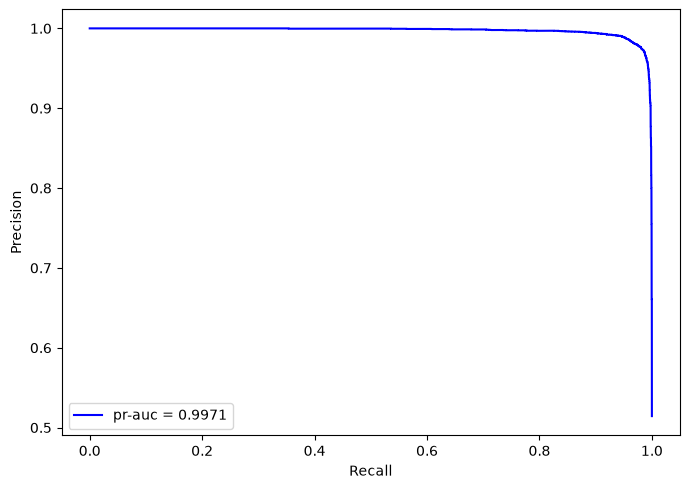

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='blue', label=f'pr-auc = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

## Логистическая регрессия для фейк/реальная


In [44]:
train_data = load_npz("x_train_cat_tfidf.npz")
test_data  = load_npz("x_test_cat_tfidf.npz")

In [45]:
X_train = train_data[:, :-1]
y_train = np.array(train_data[:, -1].todense()).ravel().astype(int)
X_test = test_data[:, :-1]
y_test  = np.array(test_data[:, -1].todense()).ravel().astype(int)

In [46]:
par = {"C": np.logspace(-1, 1, 5)}
scoring = {"roc_auc":"roc_auc_ovr",
    "precision":make_scorer(precision_score, average="macro", zero_division=0),
    "recall":make_scorer(recall_score,    average="macro", zero_division=0),
    "f1":make_scorer(f1_score,        average="macro", zero_division=0),}

In [47]:
grid = GridSearchCV(LogisticRegression(max_iter=1000, solver="saga"),param_grid=par,
    cv=3,scoring=scoring,refit="roc_auc",verbose=1)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'C': array([ 0.1 ... 10. ])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), 'recall': make_scorer(r...ro_division=0), 'roc_auc': 'roc_auc_ovr'}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation

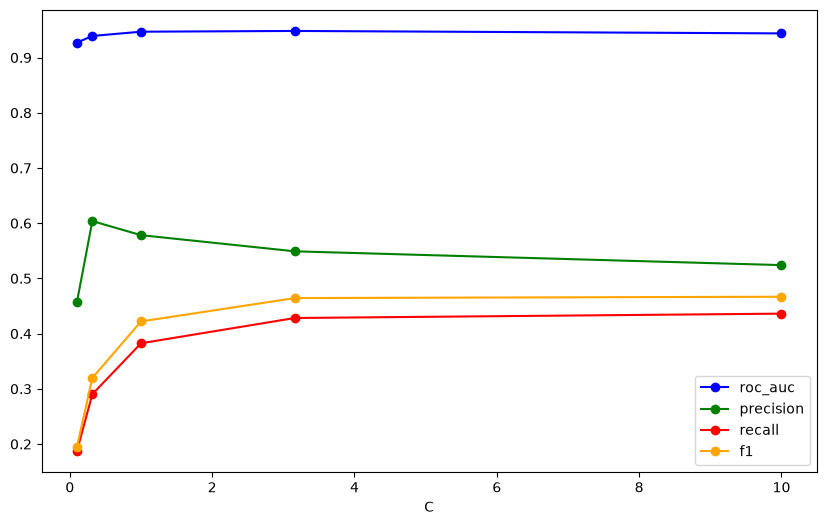

In [48]:
res = grid.cv_results_
c = res["param_C"].data.astype(float)
plt.figure(figsize=(10, 6))
for m, col in [("roc_auc", "blue"), ("precision", "green"), ("recall", "red"), ("f1", "orange")]:
    scores = res[f"mean_test_{m}"]
    plt.plot(c, scores, marker="o", color=col, label=m)
plt.xlabel("C")
plt.legend()

In [ ]:
le_classes = np.array([
    'ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE',
    'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION',
    'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK',
    'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT',
    'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS',
    'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS',
    'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST',
    'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS',
    'WOMEN', 'WORLD NEWS', 'WORLDPOST'
])ы

In [53]:
print(f"рок macro: {auc}")
print(f"рок micro: {auc_micro}")
print(f"пр-аук  macro: {pr_auc_macro}")
print(f"пр-аук  micro: {pr_auc_micro}")

рок macro: 0.9553209901439293
рок micro: 0.9694414125987484
пр-аук  macro: 0.5029561948271768
пр-аук  micro: 0.6703084349223492


In [57]:
grid.best_estimator_.multi_class = 'auto'
pickle.dump(grid.best_estimator_, open('model_categories2.pkl', 'wb'))